# Cats vs Dogs Classification using EfficientNetB0 Transfer Learning

In this notebook, a deep learning model is developed to classify images of cats and dogs using Transfer Learning with EfficientNetB0. The Cats vs Dogs dataset is loaded and divided into training and validation sets. The images are preprocessed using the EfficientNet preprocessing function before being passed to the pretrained network.

A pretrained EfficientNetB0 model is used as the feature extraction backbone with the original classification head removed. Custom classification layers are added for the binary classification task. Feature extraction is first performed with all pretrained layers frozen, allowing only the custom layers to learn the new task.

The model is then fine-tuned by unfreezing selected layers and retraining with a smaller learning rate. Fine-tuning helps the network adapt ImageNet features to the Cats vs Dogs dataset and generally improves validation accuracy.

The final model is evaluated, the trained weights are saved, and the results are compared with MobileNetV2 and ResNet50V2 to analyze the trade-off between accuracy, model size, and training efficiency.


In [1]:
!pip install -U protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.1 which is incompatible.
google-cloud-aiplatform 1.157.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requ

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [3]:
(train_ds, val_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.LHD9AE_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [4]:
IMG_SIZE = (160, 160)

def resize(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_ds = train_ds.map(resize)
val_ds = val_ds.map(resize)

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.batch(32).prefetch(AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(AUTOTUNE)

In [6]:
base = tf.keras.applications.EfficientNetB0(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
inputs = tf.keras.Input(shape=(160, 160, 3))

x =  tf.keras.applications.efficientnet.preprocess_input(inputs)

x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 199s 198ms/step - accuracy: 0.9542 - loss: 0.1188 - val_accuracy: 0.9695 - val_loss: 0.0763
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 58s 99ms/step - accuracy: 0.9786 - loss: 0.0569 - val_accuracy: 0.9665 - val_loss: 0.0996
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.9869 - loss: 0.0389 - val_accuracy: 0.9757 - val_loss: 0.0835
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 90ms/step - accuracy: 0.9878 - loss: 0.0360 - val_accuracy: 0.9663 - val_loss: 0.1143
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 90ms/step - accuracy: 0.9881 - loss: 0.0342 - val_accuracy: 0.9740 - val_loss: 0.0744
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 92ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9725 - val_loss: 0.0825
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.9920 - loss: 0.0218 - val_accuracy: 0.9774 - val_loss: 0.0673
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 90ms/step - accuracy: 0.9917 - loss: 0.0221 

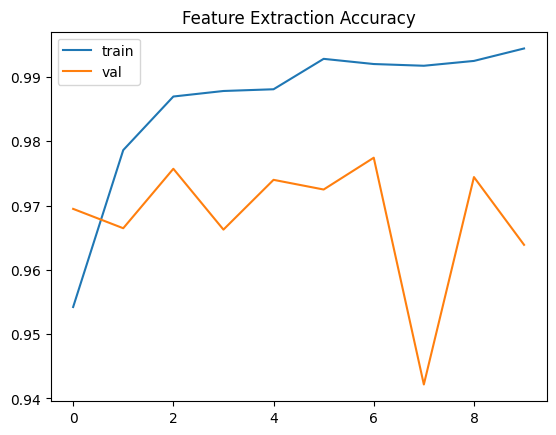

In [10]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Feature Extraction Accuracy")
plt.show()

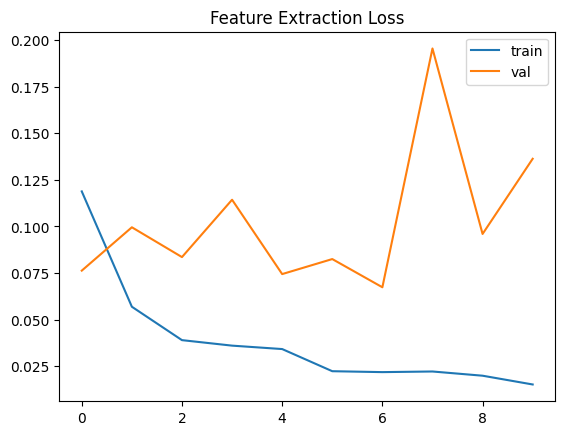

In [11]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Feature Extraction Loss")
plt.show()

In [12]:
model.save("cats_dogs_feature_extraction.keras")

In [13]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9639 - loss: 0.1363
Validation Accuracy: 0.9638864994049072


In [14]:
import os
print(os.listdir())

['.config', 'cats_dogs_feature_extraction.keras', 'sample_data']


In [15]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/cats_dogs_feature_extraction.keras")

Mounted at /content/drive


# Cats vs Dogs — Fine-Tuning Phase (Transfer Learning)

## Today's Goal
In this phase, we improve the previously trained feature extraction model by unfreezing the top layers of the MobileNetV2 base model and fine-tuning it with a very small learning rate (1e-5). This allows the pretrained model to adapt slightly to the Cats vs Dogs dataset without destroying learned ImageNet features.

---

## Steps Followed

1. Loaded the previously saved feature extraction model (`cats_dogs_feature_extraction.keras`).
2. Retrieved the MobileNetV2 base model from the architecture.
3. Unfroze only the last ~30 layers of the base model while keeping earlier layers frozen.
4. Recompiled the model using a very small learning rate (`1e-5`) to avoid disrupting pretrained weights.
5. Trained the model for additional epochs on the same dataset.
6. Monitored training and validation accuracy to evaluate improvement over feature extraction phase.
7. Saved the final fine-tuned model as `cats_dogs_finetuned.keras`.

---

## Key Concept
Fine-tuning allows the pretrained model to adjust high-level features to better fit the target dataset. This step usually improves accuracy beyond the feature extraction stage.

---

## Expected Outcome
- Higher validation accuracy than feature extraction phase (~95% → ~97–98%)
- Better generalization on unseen images
- Slight reduction in training-validation gap

In [16]:
import tensorflow as tf

model = tf.keras.models.load_model("cats_dogs_feature_extraction.keras")

In [17]:
base_model = model.layers[1]  # sometimes index may differ, adjust if needed

base_model.trainable = True

In [18]:
for layer in base_model.layers:
    layer.trainable = False

In [19]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # VERY SMALL LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 74s 93ms/step - accuracy: 0.9529 - loss: 0.1238 - val_accuracy: 0.9774 - val_loss: 0.0758
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.9769 - loss: 0.0615 - val_accuracy: 0.9815 - val_loss: 0.0604
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.9861 - loss: 0.0388 - val_accuracy: 0.9830 - val_loss: 0.0569
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9918 - loss: 0.0245 - val_accuracy: 0.9822 - val_loss: 0.0562
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.9959 - loss: 0.0165 - val_accuracy: 0.9824 - val_loss: 0.0556
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.9987 - loss: 0.0104 - val_accuracy: 0.9826 - val_loss: 0.0569
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9990 - loss: 0.0073 - val_accuracy: 0.9819 - val_loss: 0.0576
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.9994 - loss: 0.0048 - 

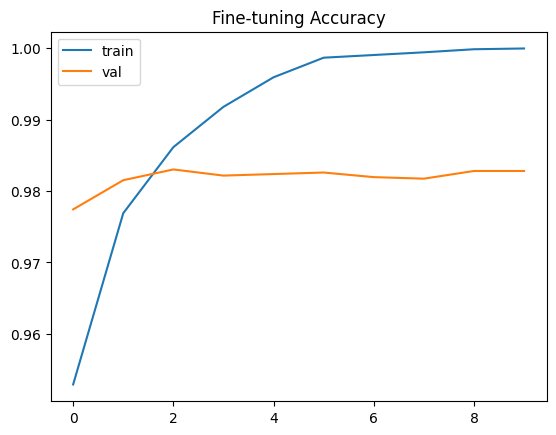

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_fine.history["accuracy"], label="train")
plt.plot(history_fine.history["val_accuracy"], label="val")
plt.legend()
plt.title("Fine-tuning Accuracy")
plt.show()

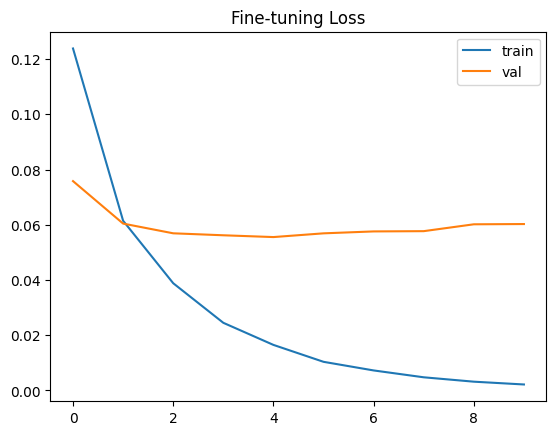

In [ ]:
plt.plot(history_fine.history["loss"], label="train")
plt.plot(history_fine.history["val_loss"], label="val")
plt.legend()
plt.title("Fine-tuning Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Final Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9828 - loss: 0.0603
Final Validation Accuracy: 0.9828031063079834


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━

In [ ]:
import matplotlib.pyplot as plt

wrong_images = []
wrong_labels = []
wrong_preds = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    for i in range(len(labels)):
        if preds[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_labels.append(labels[i].numpy())
            wrong_preds.append(preds[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
